# Notebook to Analyse Demo Results

### Content
- Plots GT vs Our Sensor for Demo day results
    - Computes the Error, Uncertainty etc
- Loads data from last sensor readings
    - Used to breakdown characteristics of individual sensors

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cell 2: Load the CSV data from file
# Replace 'your_file.csv' with your actual file path
df = pd.read_csv('data/demo/Last-test.csv')
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully!
Shape: (34696, 13)


,timestamp_iso,timestamp_epoch,t_rel_s,device_name,port,value_raw_mps,value_clipped_mps,expected_error_pct,cov_lower_mps,cov_upper_mps,raw_serial_line,csv_col_0,csv_col_1
0,2025-11-20T10:43:57.426Z,812.647777,88.580953,Student,/dev/ttyACM1,0.00,0.0,NaN,NaN,NaN,"0.0366, 0",0.0366,0.0
1,2025-11-20T10:43:57.426Z,812.648053,88.581229,Ground Truth,/dev/ttyACM0,-0.34,0.0,NaN,NaN,NaN,-0.34,-0.3400,NaN
2,2025-11-20T10:43:57.426Z,812.649599,88.582775,Student,/dev/ttyACM1,0.00,0.0,NaN,NaN,NaN,"0.0468, 0",0.0468,0.0
3,2025-11-20T10:43:57.426Z,812.651629,88.584805,Ground Truth,/dev/ttyACM0,-0.33,0.0,NaN,NaN,NaN,-0.33,-0.3300,NaN
4,2025-11-20T10:43:57.426Z,812.654546,88.587722,Ground Truth,/dev/ttyACM0,-0.33,0.0,NaN,NaN,NaN,-0.33,-0.3300,NaN


In [3]:
# Cell 3: Display data info and check for missing values
print("Dataset Information:")
print(df.info())
print("\n" + "="*60)
print("\nMissing values:")
print(df.isnull().sum())
print("\n" + "="*60)
print("\nColumn names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34696 entries, 0 to 34695
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp_iso       34696 non-null  object 
 1   timestamp_epoch     34696 non-null  float64
 2   t_rel_s             34696 non-null  float64
 3   device_name         34696 non-null  object 
 4   port                34696 non-null  object 
 5   value_raw_mps       34696 non-null  float64
 6   value_clipped_mps   34696 non-null  float64
 7   expected_error_pct  12014 non-null  float64
 8   cov_lower_mps       12014 non-null  float64
 9   cov_upper_mps       12014 non-null  float64
 10  raw_serial_line     34696 non-null  object 
 11  csv_col_0           34696 non-null  float64
 12  csv_col_1           17171 non-null  float64
dtypes: float64(9), object(4)
memory usage: 3.4+ MB
None


Missing values:
timestamp_iso             0
timestamp_epoch           0
t_re

In [4]:
# Cell 4: Extract Ground Truth data
ground_truth_df = df[df['device_name'] == 'Ground Truth'][['timestamp_iso', 't_rel_s', 'csv_col_0']].copy()

print(f"Ground Truth records: {len(ground_truth_df)}")
print("\nGround Truth data:")
ground_truth_df.head(10)

Ground Truth records: 17525

Ground Truth data:


,timestamp_iso,t_rel_s,csv_col_0
1,2025-11-20T10:43:57.426Z,88.581229,-0.34
3,2025-11-20T10:43:57.426Z,88.584805,-0.33
4,2025-11-20T10:43:57.426Z,88.587722,-0.33
6,2025-11-20T10:43:57.426Z,88.590261,-0.33
8,2025-11-20T10:43:57.426Z,88.594907,-0.33
10,2025-11-20T10:43:57.426Z,88.599680,-0.33
12,2025-11-20T10:43:57.426Z,88.604518,-0.33
14,2025-11-20T10:43:57.459Z,88.612802,-0.33
16,2025-11-20T10:43:57.459Z,88.615159,-0.33
18,2025-11-20T10:43:57.459Z,88.620845,-0.33


In [5]:
student_df = df[df['device_name'] == 'Student'][['timestamp_iso', 't_rel_s', 'csv_col_0','csv_col_1']].copy()
print(f"Student records: {len(student_df)}")
print("\nStudent data:")
student_df.head(10)

Student records: 17171

Student data:


,timestamp_iso,t_rel_s,csv_col_0,csv_col_1
0,2025-11-20T10:43:57.426Z,88.580953,0.0366,0.0
2,2025-11-20T10:43:57.426Z,88.582775,0.0468,0.0
5,2025-11-20T10:43:57.426Z,88.589644,0.0430,0.0
7,2025-11-20T10:43:57.426Z,88.593580,0.0414,0.0
9,2025-11-20T10:43:57.426Z,88.597568,0.0441,0.0
11,2025-11-20T10:43:57.426Z,88.602551,0.0445,0.0
13,2025-11-20T10:43:57.426Z,88.607381,0.0393,0.0
15,2025-11-20T10:43:57.459Z,88.615140,0.0411,0.0
17,2025-11-20T10:43:57.459Z,88.618079,0.0379,0.0
19,2025-11-20T10:43:57.459Z,88.623209,0.0432,0.0


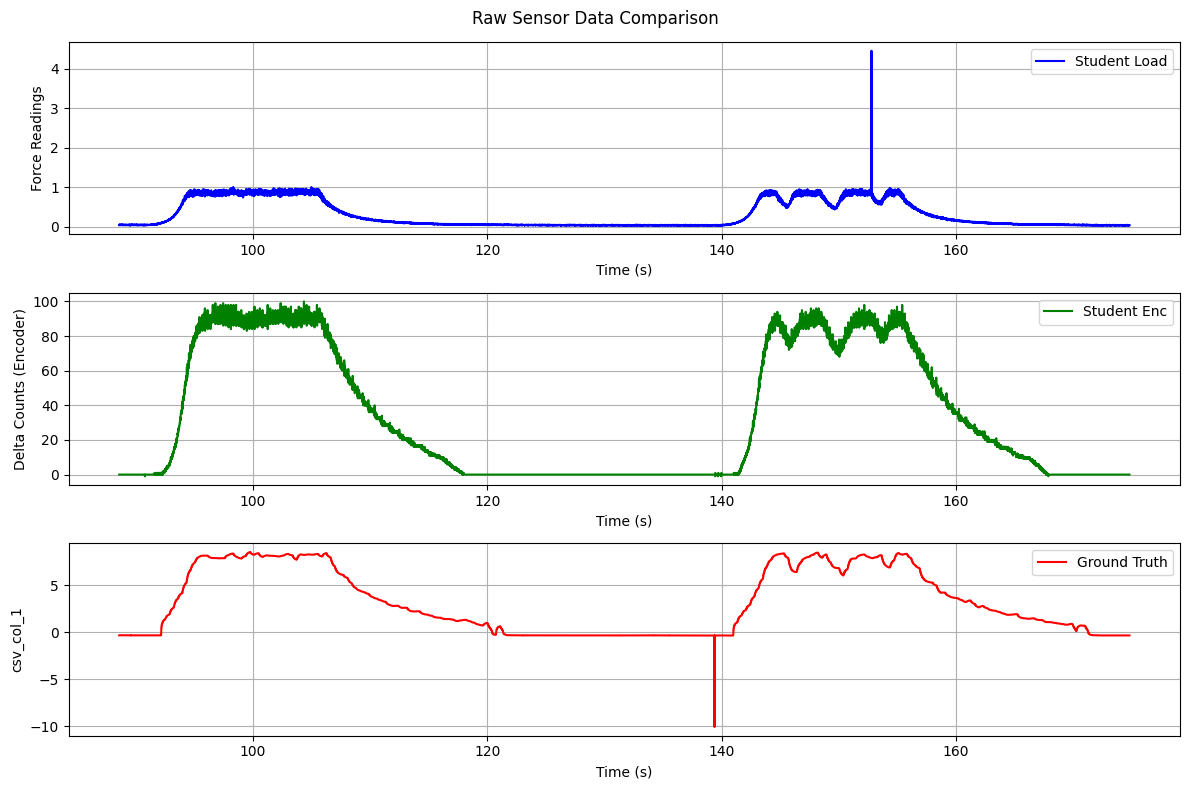

In [6]:
# Create figure with 2 subplots stacked vertically
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle('Raw Sensor Data Comparison')

# First subplot:  Load Cell (N)
ax1.plot(student_df['t_rel_s'], student_df['csv_col_0'], label='Student Load', color='blue')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Force Readings')
ax1.legend()
ax1.grid(True)

# Second subplot: Delta Encoder Counts from student data
ax2.plot(student_df['t_rel_s'], student_df['csv_col_1'], label='Student Enc', color='green')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Delta Counts (Encoder)')
ax2.legend()
ax2.grid(True)

#Third Subplot: Ground Truth
ax3.plot(ground_truth_df['t_rel_s'], ground_truth_df['csv_col_0'], label='Ground Truth', color='red')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('csv_col_1')
ax3.legend()
ax3.grid(True)


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [7]:
# Clean some of the outliers from load cell data

# find number of values greater than 1
load_outlier_threshold = 1.0
num_outliers = (student_df['csv_col_0'] > load_outlier_threshold).sum()
print(f"Number of outliers Load Cell > {load_outlier_threshold}): {num_outliers}")

# Remove the outliers
student_df = student_df[student_df['csv_col_0'] <= load_outlier_threshold]

Number of outliers Load Cell > 1.0): 2


In [8]:
# Clean outliers from ground truth data
gt_outlier_threshold = -1.0
num_gt_outliers = (ground_truth_df['csv_col_0'] < gt_outlier_threshold).sum()
print(f"Number of outliers Ground Truth < {gt_outlier_threshold}): {num_gt_outliers}")
ground_truth_df = ground_truth_df[ground_truth_df['csv_col_0'] >= gt_outlier_threshold]

Number of outliers Ground Truth < -1.0): 2


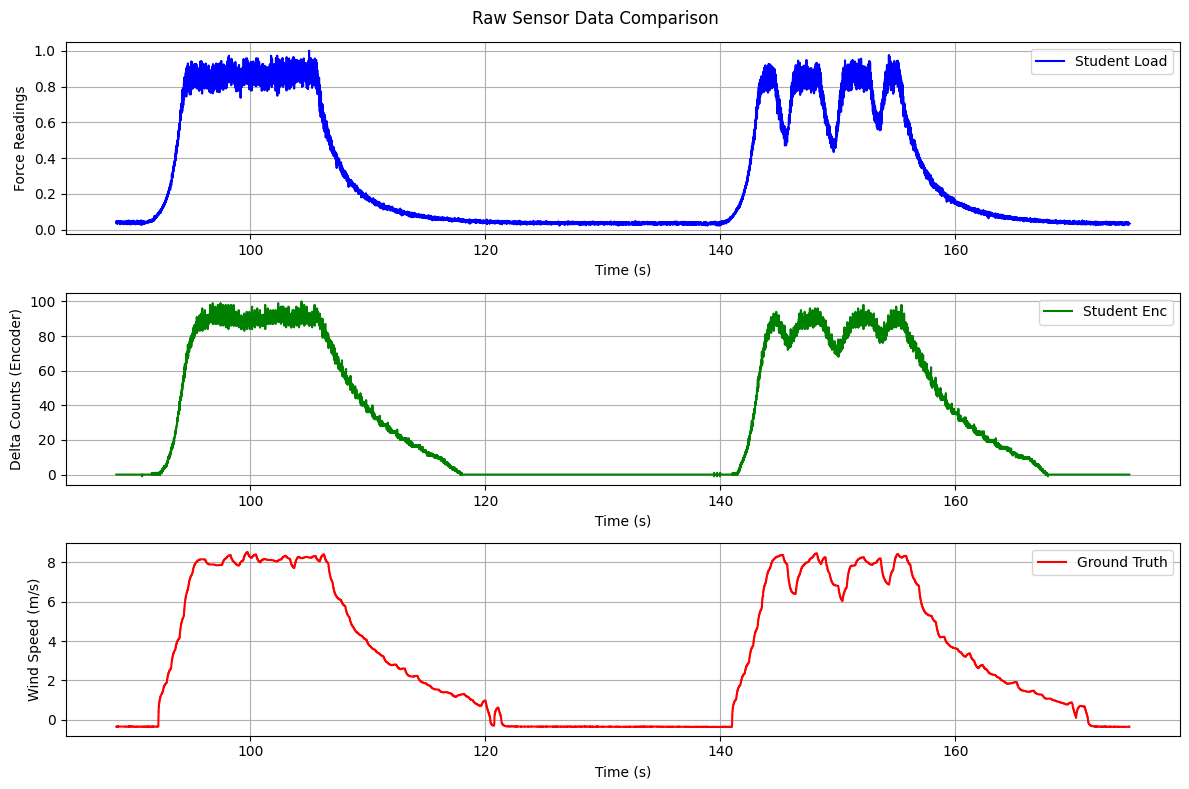

In [9]:
# Display cleaned data info
# Create figure with 2 subplots stacked vertically
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle('Raw Sensor Data Comparison')

# First subplot:  Load Cell (N)
ax1.plot(student_df['t_rel_s'], student_df['csv_col_0'], label='Student Load', color='blue')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Force Readings')
ax1.legend()
ax1.grid(True)

# Second subplot: Delta Encoder Counts from student data
ax2.plot(student_df['t_rel_s'], student_df['csv_col_1'], label='Student Enc', color='green')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Delta Counts (Encoder)')
ax2.legend()
ax2.grid(True)

#Third Subplot: Ground Truth
ax3.plot(ground_truth_df['t_rel_s'], ground_truth_df['csv_col_0'], label='Ground Truth', color='red')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Wind Speed (m/s)')
ax3.legend()
ax3.grid(True)


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [ ]:
# Transform to individual velocity outputs
Load_Cell_Raw = student_df['csv_col_0']
Encoder_Raw = student_df['csv_col_1']
t_rel_s = student_df['t_rel_s']


# LOAD CELL 
v_load_coeff = 0.5 * 1.225 * 0.12 * 0.15 * 1.28
V_Load = Load_Cell_Raw / v_load_coeff
V_Load = np.where(V_Load > 0, np.sqrt(V_Load), 0)

# Encoder
encoder_coeff = 0.069776
encoder_coeff = 0.075

encoder_bias =  0.916736
V_Enc = (encoder_coeff * Encoder_Raw) + encoder_bias

vel_load_df = pd.DataFrame({'t_rel_s': t_rel_s, 'V_Load': V_Load})
vel_encoder_df = pd.DataFrame({'t_rel_s': t_rel_s, 'V_Enc': V_Enc})

print(vel_load_df.head())
print(vel_encoder_df.head())

     t_rel_s    V_Load
0  88.580953  1.610446
2  88.582775  1.821078
5  88.589644  1.745581
7  88.593580  1.712797
9  88.597568  1.767767
     t_rel_s     V_Enc
0  88.580953  0.916947
2  88.582775  0.916947
5  88.589644  0.916947
7  88.593580  0.916947
9  88.597568  0.916947


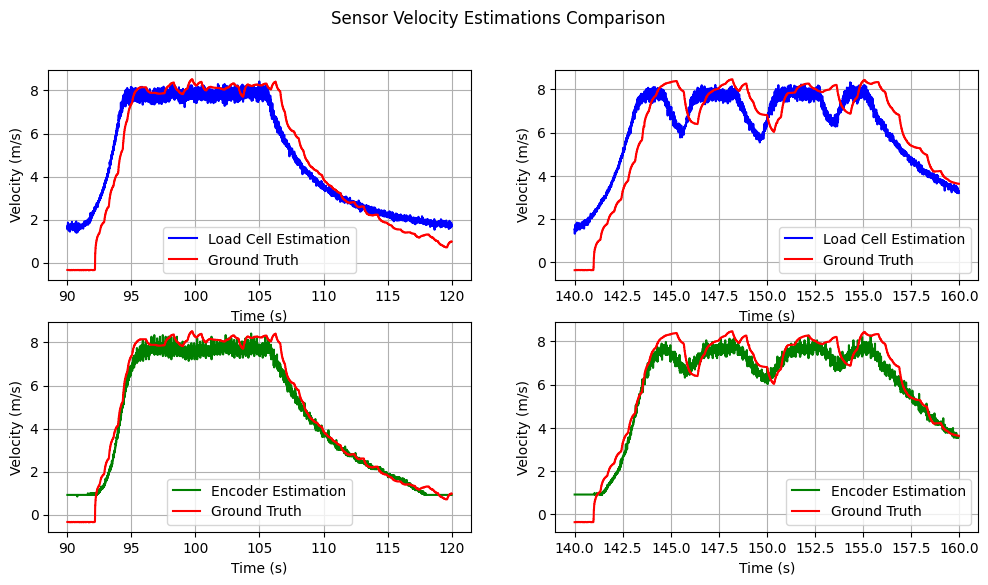

In [33]:
# create step response masks
step_min = 90.0
step_max = 120.0
step_mask_load = (vel_load_df['t_rel_s'] >= step_min) & (vel_load_df['t_rel_s'] <= step_max)
step_mask_enc = (vel_encoder_df['t_rel_s'] >= step_min) & (vel_encoder_df['t_rel_s'] <= step_max)
step_mask_gt = (ground_truth_df['t_rel_s'] >= step_min) & (ground_truth_df['t_rel_s'] <= step_max)

# create impulse response masks
impulse_min = 140.0
impulse_max = 160.0
impulse_mask_load = (vel_load_df['t_rel_s'] >= impulse_min) & (vel_load_df['t_rel_s'] <= impulse_max)
impulse_mask_enc = (vel_encoder_df['t_rel_s'] >= impulse_min) & (vel_encoder_df['t_rel_s'] <= impulse_max)
impulse_mask_gt = (ground_truth_df['t_rel_s'] >= impulse_min) & (ground_truth_df['t_rel_s'] <= impulse_max)

# Plot the four overlayed with the ground truth
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
ax1, ax2, ax3, ax4 = axes.flatten()

fig.suptitle('Sensor Velocity Estimations Comparison')
# First subplot:  Load Cell (N) (Step Response)
ax1.plot(vel_load_df.loc[step_mask_load, 't_rel_s'], vel_load_df.loc[step_mask_load, 'V_Load'], label='Load Cell Estimation', color='blue')
ax1.plot(ground_truth_df.loc[step_mask_gt, 't_rel_s'], ground_truth_df.loc[step_mask_gt, 'csv_col_0'], label='Ground Truth', color='red')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Velocity (m/s)')
ax1.legend()
ax1.grid(True)

# Second subplot: Load Cell Estimate (Impulse Response)
ax2.plot(vel_load_df.loc[impulse_mask_load, 't_rel_s'], vel_load_df.loc[impulse_mask_load, 'V_Load'], label='Load Cell Estimation', color='blue')
ax2.plot(ground_truth_df.loc[impulse_mask_gt, 't_rel_s'], ground_truth_df.loc[impulse_mask_gt, 'csv_col_0'], label='Ground Truth', color='red')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Velocity (m/s)')
ax2.legend()
ax2.grid(True)

# Third subplot: Encoder Estimate (Step Response)
ax3.plot(vel_encoder_df.loc[step_mask_enc, 't_rel_s'], vel_encoder_df.loc[step_mask_enc, 'V_Enc'], label='Encoder Estimation', color='green')
ax3.plot(ground_truth_df.loc[step_mask_gt, 't_rel_s'], ground_truth_df.loc[step_mask_gt, 'csv_col_0'], label='Ground Truth', color='red')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Velocity (m/s)')
ax3.legend()
ax3.grid(True)


# Fourth subplot: Encoder Estimate (Impulse Response)
ax4.plot(vel_encoder_df.loc[impulse_mask_enc, 't_rel_s'], vel_encoder_df.loc[impulse_mask_enc, 'V_Enc'], label='Encoder Estimation', color='green')
ax4.plot(ground_truth_df.loc[impulse_mask_gt, 't_rel_s'], ground_truth_df.loc[impulse_mask_gt, 'csv_col_0'], label='Ground Truth', color='red')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Velocity (m/s)')
ax4.legend()
ax4.grid(True)


# DEMO

In [3]:
gt_df = pd.read_csv('data/demo/GT_demo.csv')
print("GT Data loaded successfully!")
print(f"Shape: {gt_df.shape}")
gt_df.head()

GT Data loaded successfully!
Shape: (24674, 10)


,timestamp_iso,timestamp_epoch,t_rel_s,device_name,port,value_raw_mps,value_clipped_mps,expected_error_pct,cov_lower_mps,cov_upper_mps
0,2025-10-30T12:10:21.669Z,211811.545275,45.039151,Ground Truth,/dev/tty.usbmodem141303,-0.35,-0.35,420.367,-1.821286,1.121286
1,2025-10-30T12:10:21.669Z,211811.545559,45.039434,Ground Truth,/dev/tty.usbmodem141303,-0.35,-0.35,420.367,-1.821286,1.121286
2,2025-10-30T12:10:21.669Z,211811.545838,45.039713,Ground Truth,/dev/tty.usbmodem141303,-0.35,-0.35,420.367,-1.821286,1.121286
3,2025-10-30T12:10:21.669Z,211811.546308,45.040184,Ground Truth,/dev/tty.usbmodem141303,-0.34,-0.34,445.459,-1.854559,1.174559
4,2025-10-30T12:10:21.670Z,211811.547038,45.040913,Ground Truth,/dev/tty.usbmodem141303,-0.34,-0.34,445.459,-1.854559,1.174559


In [4]:
st_df = pd.read_csv('data/demo/Student_demo.csv')
print("Student Data loaded successfully!")
print(f"Shape: {st_df.shape}")
st_df.head()

Student Data loaded successfully!
Shape: (24175, 10)


,timestamp_iso,timestamp_epoch,t_rel_s,device_name,port,value_raw_mps,value_clipped_mps,expected_error_pct,cov_lower_mps,cov_upper_mps
0,2025-10-30T12:10:21.669Z,211811.545521,45.039396,Student,/dev/cu.usbmodem141403,1.1012,1.1012,NaN,NaN,NaN
1,2025-10-30T12:10:21.669Z,211811.545820,45.039696,Student,/dev/cu.usbmodem141403,1.1007,1.1007,NaN,NaN,NaN
2,2025-10-30T12:10:21.669Z,211811.546112,45.039987,Student,/dev/cu.usbmodem141403,1.1038,1.1038,NaN,NaN,NaN
3,2025-10-30T12:10:21.669Z,211811.546445,45.040320,Student,/dev/cu.usbmodem141403,1.1070,1.1070,NaN,NaN,NaN
4,2025-10-30T12:10:21.670Z,211811.547906,45.041781,Student,/dev/cu.usbmodem141403,1.1075,1.1075,NaN,NaN,NaN


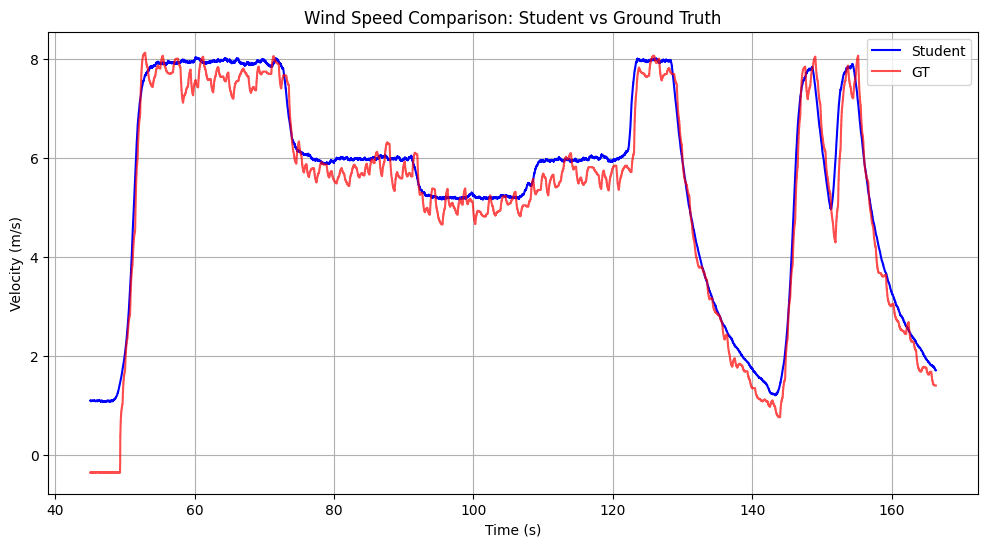

In [5]:
# Plot based on t_rel_s

plt.figure(figsize=(12, 6))
plt.plot(st_df['t_rel_s'], st_df['value_raw_mps'], label='Student', color='blue')
plt.plot(gt_df['t_rel_s'], gt_df['value_raw_mps'], label='GT', color='red', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Wind Speed Comparison: Student vs Ground Truth')
plt.legend()
plt.grid(True)